# Interpretability

CPH 200C Problem 2

Questions? Ask Professor Irene Chen (iychen@berkeley.edu)

As machine learning models become more inscrutable, we are interested in methods to better understand why our models make the decisions they do --- and as a result whether we can trust them. To address this problem, we typically apply either post-hoc explanations to trained models or restrict our models to specific classes that are deemed more easily understandable. The goal of this section of the problem set is to familiarize you with the SHAP values package to apply interpretability methods to the diabetes dataset we have already explored.


In [1]:
%reload_ext autoreload
%autoreload 2

import sys
import os

path_to_project = os.path.abspath(os.path.join(os.getcwd(), '../'))    
sys.path.insert(1, os.path.join(path_to_project))

# 1. SHAP Values

## 1.0 Load packages

In [2]:
%matplotlib inline
import pandas as pd
import numpy as np

from scipy.stats import zscore
from sklearn.preprocessing import normalize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

import xgboost
import shap

from src.directory import cph_200C_dir

# change to location of unzipped csv files
fname_adult_icu   = os.path.join(cph_200C_dir, 'adult_icu.csv')
fname_adult_notes =  os.path.join(cph_200C_dir, 'adult_notes_subsample.csv')

/home/hentipapai/miniconda3/envs/cph200C/lib/python3.12/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/home/hentipapai/miniconda3/envs/cph200C/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
adult_df    = pd.read_csv(fname_adult_icu)
notes_df    = pd.read_csv(fname_adult_notes)

In [4]:
adult_df.describe()

,subject_id,hadm_id,icustay_id,age,mort_hosp,mort_icu,mort_oneyr,first_hosp_stay,first_icu_stay,adult_icu,...,phosphate,platelet,potassium,ptt,inr,pt,sodium,bun,wbc,train
count,27348.000000,27348.000000,27348.000000,27348.000000,27348.000000,27348.000000,27348.000000,27348.000000,27348.000000,27348.0,...,27348.000000,27348.000000,27348.000000,27348.000000,27348.000000,27348.000000,27348.000000,27348.000000,27348.000000,27348.000000
mean,34989.173066,149950.302582,249877.025998,63.233984,0.140449,0.098398,0.141473,0.770257,0.915826,1.0,...,3.775182,237.071216,4.245273,38.052775,1.589497,16.415372,137.951895,28.624918,12.762698,0.704183
std,28568.351341,28942.158352,28831.221224,16.080696,0.347459,0.297858,0.348515,0.420675,0.277654,0.0,...,1.416410,131.234927,0.843269,22.688517,1.197619,8.354497,5.259926,23.414337,10.034755,0.456417
min,3.000000,100001.000000,200001.000000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,...,0.300000,5.000000,1.200000,12.600000,0.500000,8.000000,84.000000,1.000000,0.100000,0.000000
25%,12351.000000,124910.250000,224955.000000,53.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.0,...,2.900000,151.000000,3.700000,26.600000,1.100000,13.100000,135.000000,14.000000,8.000000,0.000000
50%,25076.000000,149779.000000,249955.000000,65.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.0,...,3.600000,216.000000,4.100000,31.500000,1.300000,14.400000,138.000000,21.000000,11.300000,1.000000
75%,56639.750000,175155.000000,274719.000000,76.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.0,...,4.300000,296.000000,4.600000,39.000000,1.600000,16.600000,141.000000,35.000000,15.600000,1.000000
max,99995.000000,199999.000000,299995.000000,89.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,...,17.300000,2292.000000,13.800000,150.000000,39.900000,150.000000,182.000000,272.000000,600.200000,1.000000


In [5]:
notes_df.describe()

,subject_id,hadm_id,icustay_id,train,mort_hosp,mort_icu,mort_oneyr
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,33517.507000,149483.106800,249748.686133,0.703600,0.137333,0.095667,0.138267
std,28067.659379,28843.232939,28755.385712,0.456685,0.344210,0.294143,0.345191
min,3.000000,100009.000000,200001.000000,0.000000,0.000000,0.000000,0.000000
25%,11765.000000,124460.500000,224977.500000,0.000000,0.000000,0.000000,0.000000
50%,24029.000000,149046.500000,249838.000000,1.000000,0.000000,0.000000,0.000000
75%,53534.000000,174364.000000,274325.250000,1.000000,0.000000,0.000000,0.000000
max,99995.000000,199994.000000,299994.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
# remove columns with missing values
adult_df.dropna(axis=1, inplace=True) # remove columns with missing values

## 1.1 Tabular Data From Clinical Data

Below please find some simple data cleaning. You may substitute if you prefer your own data cleaning pipeline

In [7]:
excl_col = set(['subject_id', 'hadm_id', 'icustay_id', 'mort_oneyr', 'mort_hosp',
                'adult_icu', 'train', 'mort_icu', 'valid'])
binary_col = set(['first_hosp_stay', 'first_icu_stay', 'adult_icu',
       'eth_asian', 'eth_black', 'eth_hispanic', 'eth_other', 'eth_white',
       'admType_ELECTIVE', 'admType_EMERGENCY', 'admType_NEWBORN',
       'admType_URGENT'])
target_col = 'mort_icu'
zscore_col = [i for i in adult_df.columns if i not in excl_col and i not in binary_col] # assumes non-binary features are continuous

feature_col = [i for i in adult_df.columns if i not in excl_col]

# We want to zscore the non-binary features
adult_df[feature_col] = adult_df[feature_col].apply(zscore)


Here we are training an XGBoost model to predict ICU mortality from the tabular MIMIC-III data.

In [8]:
# Create a train/test split
is_train = adult_df['train'] == 1
is_test = adult_df['train'] == 0

X = adult_df[feature_col]
X_train = adult_df[is_train][feature_col]
y_train = adult_df[is_train][target_col]

X_test = adult_df[is_test][feature_col]
y_test = adult_df[is_test][target_col]

In [9]:
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7)
d_train = xgboost.DMatrix(X_train, label=y_train)
d_test = xgboost.DMatrix(X_test, label=y_test)

# Define parameters for the model
params = {
    "eta": 0.01,
    "objective": "binary:logistic",
    "subsample": 0.5,
    "base_score": np.mean(y_train),
    "eval_metric": "logloss",
    
}

# Train the model
tree_model = xgboost.train(
    params,
    d_train,
    5000,
    evals=[(d_test, "test")],
    verbose_eval=100,
    early_stopping_rounds=20,
)


[0]	test-logloss:0.32544
[100]	test-logloss:0.28373
[200]	test-logloss:0.26913
[300]	test-logloss:0.26265
[400]	test-logloss:0.25895
[500]	test-logloss:0.25695
[600]	test-logloss:0.25547
[700]	test-logloss:0.25478
[759]	test-logloss:0.25469


In [ ]:
# Import accuracy_score from sklearn
from sklearn.metrics import accuracy_score

# Make predictions
y_pred_prob = tree_model.predict(d_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

X_display = X[feature_col]

# Initialize JS visualization
shap.initjs()

# Explain the model's predictions using SHAP TreeExplainer
tree_explainer = shap.TreeExplainer(tree_model)
tree_shap_values = tree_explainer.shap_values(X)

Accuracy: 90.40%


In [ ]:
# Visualize the SHAP values for data point 100 using a force_plot
shap.force_plot(tree_explainer.expected_value, 
                 tree_shap_values[100], 
                 X.iloc[100],
                 link="logit", 
                 text_rotation=30)
# plt.tight_layout()
# plt.savefig(os.path.join(figures_dir, 'pset2/force_plot_tabular.png'), dpi=300, bbox_inches='tight')

/home/hentipapai/miniconda3/envs/cph200C/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1409: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


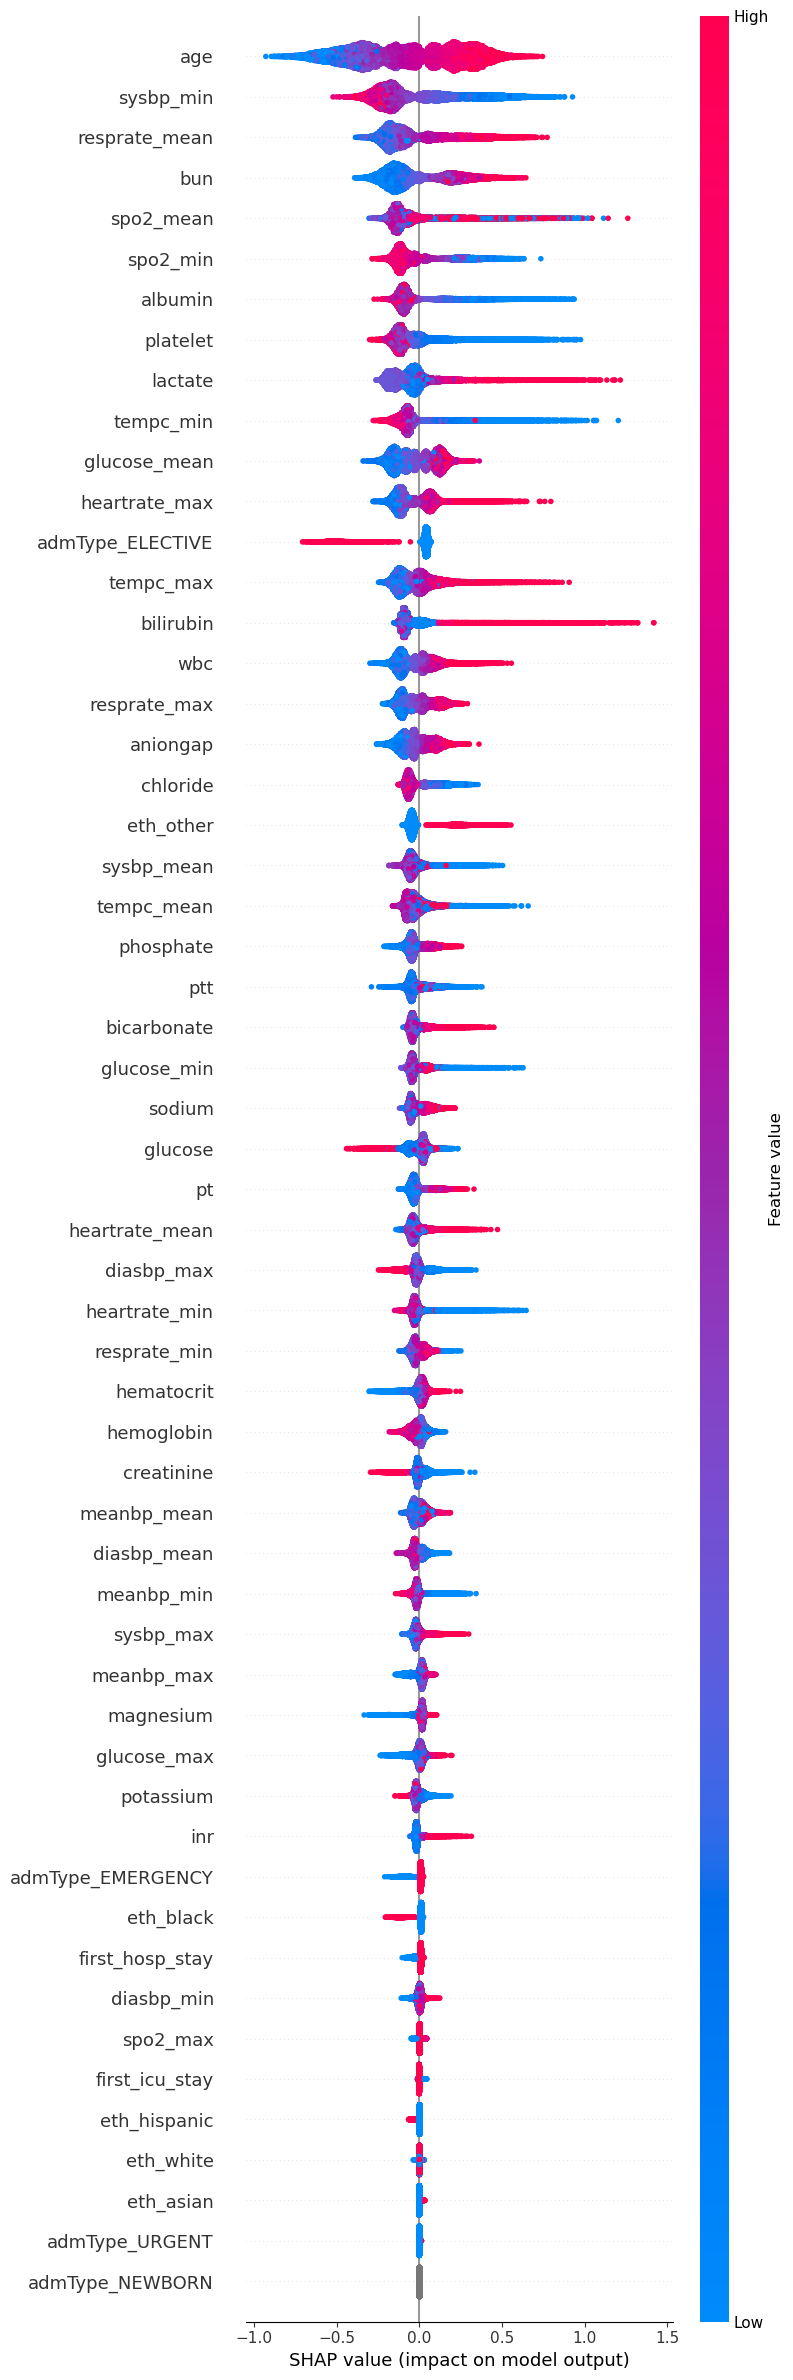

In [ ]:
# Summarize the SHAP values with a summary plot
shap.summary_plot(tree_shap_values,
                  X, 
                  max_display=X.shape[1],
                  feature_names=X.columns)

That was an example of how to use SHAP values to understand predictions from tabular data. Now let's explore how to visualize through clinical text.

In [ ]:
feature_col = 'chartext'
target_col = 'mort_icu'

ctxt = notes_df[feature_col]
vec = TfidfVectorizer(max_features=500,stop_words='english')

vec = vec.fit(ctxt)

is_train = notes_df['train'] == 1
is_test = notes_df['train'] == 0

X_train = normalize(vec.transform(notes_df[is_train][feature_col]), norm='l1', axis=0)
y_train = notes_df[is_train][target_col]

X_test = normalize(vec.transform(notes_df[is_test][feature_col]), norm='l1', axis=0)
y_test = notes_df[is_test][target_col]


In [ ]:
# SHAP 
linear_model = LinearSVC().fit(X_train, y_train)
print(f"Accuracy: {linear_model.score(X_test, y_test) * 100:.2f}%") # note: predicts constant value

# Generate SHAP values
text_to_explain = "Pt is worsening with liver failure, will transfer to surgery"
x = normalize(vec.transform([text_to_explain]), norm='l1', axis=0)

# Create explainer
linear_explainer = shap.LinearExplainer(linear_model, X_train)

# Convert sparse matrix to dense array
x_dense = x.toarray()

# Generate SHAP values for the dense array
linear_shap_values = linear_explainer.shap_values(x_dense)


Accuracy: 90.87%


In [ ]:
linear_model.predict(X_test)

array([0, 0, 0, ..., 0, 0, 0], shape=(4446,))

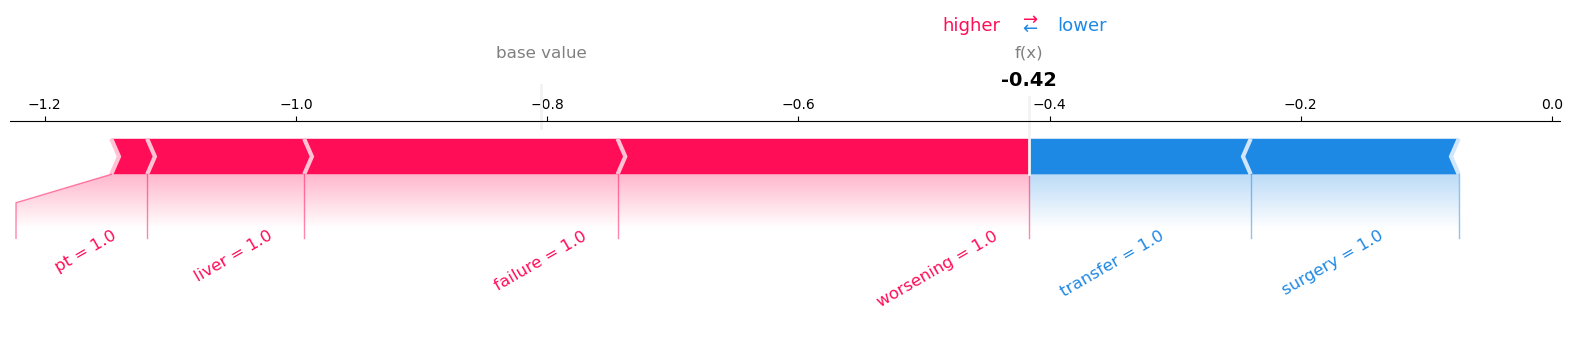

In [ ]:
# Visualize the text_to_explain using a force plot
feature_num_name_dict = {j:i for i,j in enumerate(vec.get_feature_names_out())}
features_in_text = vec.inverse_transform(x_dense)[0]
features_idx = [feature_num_name_dict[str(i)] for i in features_in_text]

shap.plots.force(linear_explainer.expected_value, 
                 linear_shap_values[:, features_idx], 
                 features=x_dense[:, features_idx], 
                 feature_names=features_in_text,
                 matplotlib=True,
                 contribution_threshold=0,
                 text_rotation=30)


# 2 Other Interpretability Methods

In [ ]:
%reload_ext autoreload
%autoreload 2

import sys
import os

path_to_project = os.path.abspath(os.path.join(os.getcwd(), '../'))    
sys.path.insert(1, os.path.join(path_to_project))

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/home/hentipapai/miniconda3/envs/cph200C/lib/python3.12/site-packages/IPython/core/interactiveshell.py", line 3667, in run_code
  File "/tmp/ipykernel_258547/3119635262.py", line 1, in <module>
    get_ipython().run_line_magic('reload_ext', 'autoreload')
  File "/home/hentipapai/miniconda3/envs/cph200C/lib/python3.12/site-packages/IPython/core/interactiveshell.py", line 2486, in run_line_magic
  File "/home/hentipapai/miniconda3/envs/cph200C/lib/python3.12/site-packages/IPython/core/magics/extension.py", line 63, in reload_ext
  File "/home/hentipapai/miniconda3/envs/cph200C/lib/python3.12/site-packages/IPython/core/extensions.py", line 121, in reload_extension
  File "/home/hentipapai/miniconda3/envs/cph200C/lib/python3.12/importlib/__init__.py", line 130, in reload
    raise ModuleNotFoundError(f"spec not found for the module {name!r}", name=name)
ModuleNotFoundError: spec not found for the module 'IPython.extensions.autoreload'

During hand

In [ ]:
import sklearn
import numpy as np
import pandas as pd
from scipy.stats import zscore
from anchor.utils import load_csv_dataset
from anchor import anchor_tabular
from src.directory import cph_200C_dir

In [ ]:
fname_adult_icu   = os.path.join(cph_200C_dir, 'adult_icu.csv')
adult_df    = pd.read_csv(fname_adult_icu)

In [ ]:
target_col = 'mort_oneyr'
excl_col = set(['subject_id', 'hadm_id', 'icustay_id', 'mort_oneyr', 'mort_hosp',
                'adult_icu', 'train', 'mort_icu', 'valid', 'admType_NEWBORN', target_col])
binary_col = set(['first_hosp_stay', 'first_icu_stay', 'adult_icu',
       'eth_asian', 'eth_black', 'eth_hispanic', 'eth_other', 'eth_white',
       'admType_ELECTIVE', 'admType_EMERGENCY', 'admType_URGENT'])
zscore_col = [i for i in adult_df.columns if i not in excl_col and i not in binary_col] # assumes non-binary, included features are continuous
binary_feature_col = [i for i in adult_df.columns if i not in excl_col and i in binary_col]

In [ ]:
# set up anchor dataset
feature_names = [*binary_feature_col, *zscore_col]
str_zscore = lambda x: zscore(x.astype(float)).astype(str)
feature_transformations = dict.fromkeys([adult_df.columns.get_loc(x) for x in zscore_col], str_zscore)
feature_transformations.update(dict.fromkeys([adult_df.columns.get_loc(x) for x in binary_feature_col], lambda x: x.astype(int).astype(str)))

dataset =  load_csv_dataset(
    fname_adult_icu, 
    target_idx=adult_df.columns.get_loc(target_col), 
    delimiter=',',
    # feature_names=feature_names,  # feature names are inferred from first row
    categorical_features=[adult_df.columns.get_loc(x) for x in binary_feature_col], # list of int
    features_to_use=[adult_df.columns.get_loc(x) for x in feature_names], # list of int
    feature_transformations=feature_transformations,
    discretize=False, 
    # balance=True, # stratified splitting
    fill_na=float('nan'), 
    filter_fn=None, 
    skip_first=True # skip header row
) 

In [ ]:
clf = sklearn.ensemble.RandomForestClassifier(n_estimators=50, n_jobs=5)
clf.fit(dataset.train, dataset.labels_train)
print('Train accuracy:', sklearn.metrics.accuracy_score(dataset.labels_train, clf.predict(dataset.train)))
print('Test accuracy:', sklearn.metrics.accuracy_score(dataset.labels_test, clf.predict(dataset.test)))

Train accuracy: 0.99949718882845
Test accuracy: 0.8811700182815356


In [ ]:
# init explainer
explainer = anchor_tabular.AnchorTabularExplainer(
    dataset.class_names,
    dataset.feature_names,
    dataset.train,
    dataset.categorical_names)

In [ ]:
# get anchor for prediction on test idx
idx = 100
np.random.seed(1)
print('Prediction: ', explainer.class_names[clf.predict(dataset.test[idx].reshape(1, -1))[0]])

Prediction:  b'0'


In [ ]:
# explain prediction
threshold = 0.95  # guarantee (with high probability) that precision will be above 0.95
exp = explainer.explain_instance(dataset.test[idx], clf.predict, threshold=threshold)
print('Anchor: %s' % (' AND '.join(exp.names())))
print('Precision: %.5f' % exp.precision())
print('Coverage: %.5f' % exp.coverage())

Anchor: b'bun' <= -0.62 AND b'eth_white' = 1
Precision: 0.98352
Coverage: 0.05060


In [ ]:
# Get test examples where the anchor applies
fit_anchor = np.where(np.all(dataset.test[:, exp.features()] == dataset.test[idx][exp.features()], axis=1))[0]
print('Anchor test precision: %.5f' % (np.mean(clf.predict(dataset.test[fit_anchor]) == clf.predict(dataset.test[idx].reshape(1, -1)))))
print('Anchor test coverage: %.5f' % (fit_anchor.shape[0] / float(dataset.test.shape[0])))

Anchor test precision: 1.00000
Anchor test coverage: 0.00037
